## 운전면허와 민증 구분

- 이번에는 운전면허와 민증을 구분해서 학습하도록 하겠습니다.
- 그리고 5차와 다르게 이미지 사이즈도 960으로 키워서 학습하도록 하겠습니다.
- 이유는 5차에서 640으로 학습시켰던 결과, 6개의 객체 중 5개를 찾는 등 놓치는 객체가 발생해서 이번에는 키워서 학습하도록 하겠습니다.

In [ ]:
%mkdir images
%mkdir labels

In [ ]:
%mkdir images/train
%mkdir images/val
%mkdir labels/train
%mkdir labels/val

In [ ]:
%%writefile data.yaml
path: .
train: images/train
val: images/train

names:
  0: license
  1: face
  2: name
  3: idnumber
  4: date
  5: place
  6: idcard

Overwriting data.yaml


In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.5 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
from matplotlib import pyplot as plt
import cv2

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
model = YOLO('yolo26m.pt')

In [ ]:
model.train(
    data="/content/data.yaml",
    epochs=150,
    imgsz=960,
    batch=10
)

Ultralytics 8.4.63 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=10, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspecti

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b02181b5eb0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
  

In [ ]:
test = YOLO('/content/runs/detect/train/weights/best.pt')

In [ ]:
result = test.predict(
    source="/content/test",
    max_det=6,
    imgsz=640,
    iou = 0.3,
    conf = 0.1
)


image 1/7 /content/test/20260608_122437.jpg: 640x640 1 face, 1 name, 1 idnumber, 1 date, 1 place, 1 idcard, 37.6ms
image 2/7 /content/test/20260608_163458.jpg: 640x640 1 face, 1 name, 1 idnumber, 1 date, 1 place, 1 idcard, 37.4ms
image 3/7 /content/test/20260609_090640.jpg: 640x640 1 license, 1 face, 1 name, 1 idnumber, 1 date, 1 place, 37.5ms
image 4/7 /content/test/20260609_091106.jpg: 640x640 1 license, 1 face, 1 name, 1 idnumber, 1 date, 1 place, 37.5ms
image 5/7 /content/test/20260609_091231.jpg: 640x640 1 license, 1 face, 1 name, 1 idnumber, 1 date, 1 place, 37.7ms
image 6/7 /content/test/20260610_104926.jpg: 640x640 1 face, 1 idnumber, 2 places, 2 idcards, 37.6ms
image 7/7 /content/test/20260610_104940.jpg: 640x640 1 face, 1 name, 1 idnumber, 1 date, 1 place, 1 idcard, 37.6ms
Speed: 3.6ms preprocess, 37.6ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)


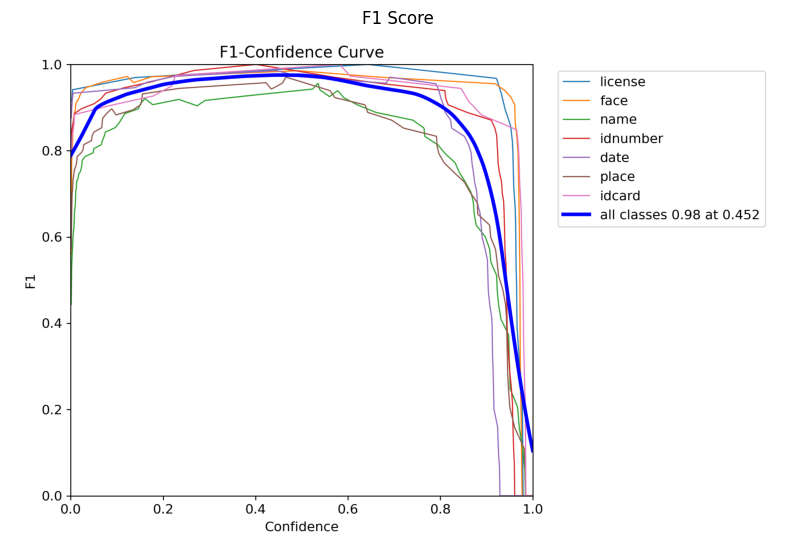

In [ ]:
img = cv2.imread('/content/runs/detect/train/BoxF1_curve.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.title('F1 Score')
plt.axis('off')
plt.show()

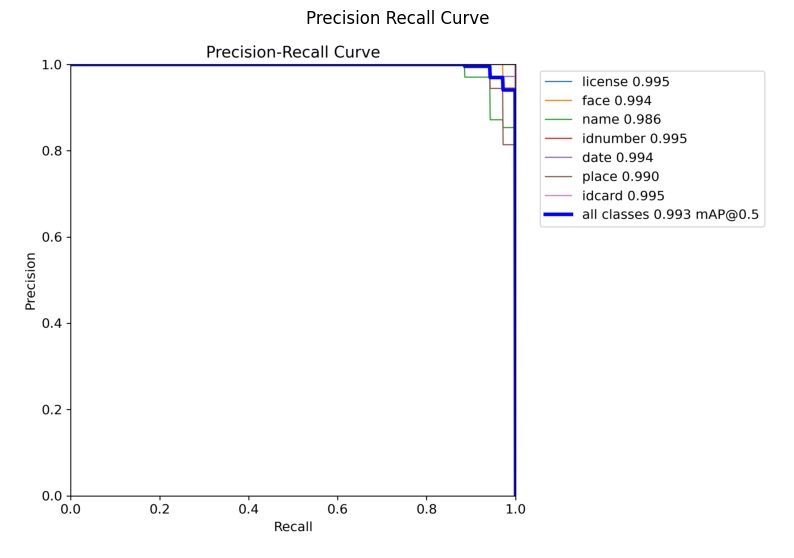

In [ ]:
img = cv2.imread('/content/runs/detect/train/BoxPR_curve.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.title('Precision Recall Curve')
plt.axis('off')
plt.show()

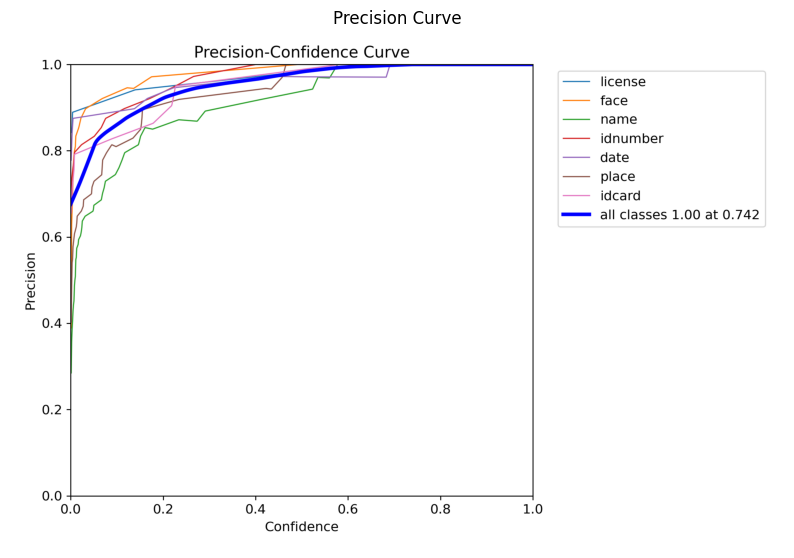

In [ ]:
img = cv2.imread('/content/runs/detect/train/BoxP_curve.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.title('Precision Curve')
plt.axis('off')
plt.show()

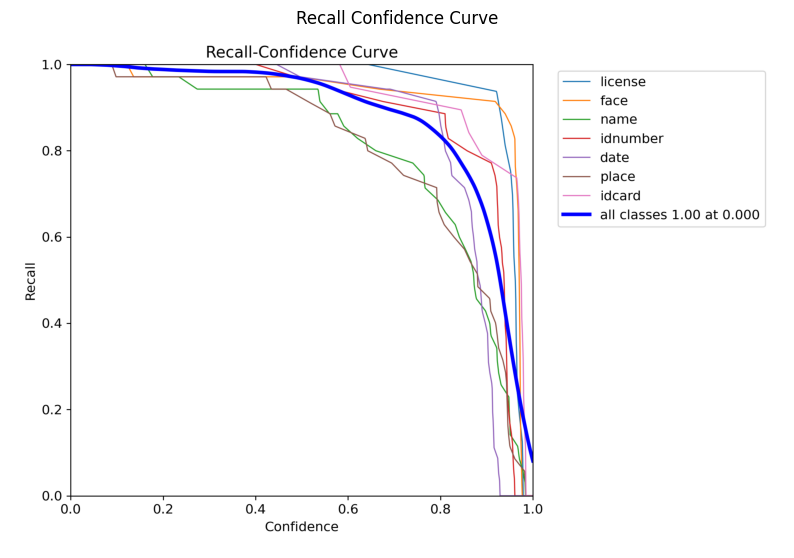

In [ ]:
img = cv2.imread('/content/runs/detect/train/BoxR_curve.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.title('Recall Confidence Curve')
plt.axis('off')
plt.show()